# D3-05 Inventory flow assessment II - criticality factors

Run this notebook in the `bw` environment after completing the Day 1 BAFU import.

In `D3-04`, we used `CF = 1.0` tracer methods to follow selected intermediates through a supply chain.
Here we switch to a **paired technosphere criticality method**: a BAFU-specific port of the `GeoPolRisk`
country-pair method from `edges`.

The case study uses three Swiss freight services with the same functional unit, `1 ton kilometer`:

- `Diesel truck`
- `Battery electric truck`
- `Fuel cell truck`


## Learning Goals

After this notebook, you should be able to:

- load a paired technosphere `edges` method from JSON and inspect its BAFU coverage report
- compare three transport services with a supply-risk indicator expressed in `kg copper-eq.`
- annotate `cf_table` rows with commodity families using the method match report
- interpret supplier-country hotspots with both a map and a Sankey diagram
- test how route choice and technology choice change the GeoPolRisk score


## Background

The original `GeoPolRisk_paired_2024.json` file in `edges` is written for ecoinvent-style suppliers.
For this course repository, we created a **BAFU-specific port** that keeps the original country-pair logic
but rewrites the supplier-side matching rules to fit the `bafu` database.

Notebook assets used here:

- `assets/d3-05/GeoPolRisk_paired_2024_bafu.json`
- `assets/d3-05/GeoPolRisk_paired_2024_bafu_summary.csv`
- `assets/d3-05/GeoPolRisk_paired_2024_bafu_matches.csv`

Important caveat:

- this is a teaching-oriented BAFU port, not an official upstream `edges` method release
- some commodity families in the original method are not present in `bafu` and are therefore dropped explicitly
- direct `GLO -> GLO` rows are removed here, because those generic pairs should instead be recovered
  through the `edges` strategy stack such as `map_aggregate_locations()`


In [1]:
from pathlib import Path
from textwrap import fill
import json
import re

import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from edges import EdgeLCIA, SupplyChain

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format

TECH_COLORS = {
    "Diesel truck": "#6b7280",
    "Battery electric truck": "#0f766e",
    "Fuel cell truck": "#ea580c",
}


def slugify(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")


In [2]:
bd.projects.set_current("aalborg-rlcia-2026")
bafu = bd.Database("bafu")

ASSETS_DIR = Path("assets/d3-05")
if not ASSETS_DIR.exists():
    ASSETS_DIR = Path("tutorials/DAY 3/assets/d3-05")

CENTROIDS_PATH = Path("assets/d3-02/country_centroids_iso2.json")
if not CENTROIDS_PATH.exists():
    CENTROIDS_PATH = Path("tutorials/DAY 3/assets/d3-02/country_centroids_iso2.json")

method_path = ASSETS_DIR / "GeoPolRisk_paired_2024_bafu.json"
method_summary = pd.read_csv(ASSETS_DIR / "GeoPolRisk_paired_2024_bafu_summary.csv")
method_matches = pd.read_csv(ASSETS_DIR / "GeoPolRisk_paired_2024_bafu_matches.csv").rename(
    columns={"name": "supplier name", "location": "supplier location"}
)
centroids = pd.DataFrame(json.loads(CENTROIDS_PATH.read_text()))

method_data = json.loads(method_path.read_text())
len(method_data["exchanges"])


42544

## 1) Select Three Comparable Freight Services

The BAFU database contains many transport datasets, but not a clean diesel vs battery-electric vs fuel-cell
**bus** trio with the same functional unit.

The clearest like-for-like comparison is therefore Swiss `32 t regional delivery` freight transport in
`ton kilometer`:

- `Diesel truck`: EURO-VI diesel service
- `Battery electric truck`: NMC-622 battery-electric service
- `Fuel cell truck`: hydrogen-from-electrolysis service

This keeps the service level consistent while still changing the upstream supply chain substantially.


In [3]:
activity_specs = {
    "Diesel truck": "Transport, freight, lorry, diesel, 32t gross weight, 2020, EURO-VI, regional delivery",
    "Battery electric truck": "Transport, freight, lorry, battery electric, NMC-622 battery, 32t gross weight, 2020, regional delivery",
    "Fuel cell truck": "Transport, freight, lorry, fuel cell electric, hydrogen from electrolysis, 32t gross weight, 2020, regional delivery",
}

activities = {
    label: next(
        act
        for act in bafu
        if act["name"] == name and act["location"] == "CH"
    )
    for label, name in activity_specs.items()
}

activity_table = pd.DataFrame(
    [
        {
            "technology": label,
            "activity name": act["name"],
            "location": act.get("location"),
            "reference product": act.get("reference product"),
            "unit": act.get("unit"),
        }
        for label, act in activities.items()
    ]
)

activity_table


,technology,activity name,location,reference product,unit
0,Diesel truck,"Transport, freight, lorry, diesel, 32t gross w...",CH,"Transport, freight, lorry, diesel, 32t gross w...",ton kilometer
1,Battery electric truck,"Transport, freight, lorry, battery electric, N...",CH,"Transport, freight, lorry, battery electric, N...",ton kilometer
2,Fuel cell truck,"Transport, freight, lorry, fuel cell electric,...",CH,"Transport, freight, lorry, fuel cell electric,...",ton kilometer


## 2) Inspect The BAFU GeoPolRisk Port

The summary file reports which original GeoPolRisk commodity families were ported successfully to `bafu`
and which ones had to be dropped.

The match report stores the exact BAFU supplier activities used by the port. We will reuse it later to
annotate `cf_table` rows with commodity-family labels.

> **Why this code exists**
>
> - **Input:** the BAFU-specific GeoPolRisk JSON, its coverage summary, and its exact supplier-match report.
> - **Purpose:** audit what the teaching port covers before interpreting any criticality score.
> - **Produces:** supported/unsupported family counts and the labels later merged onto matched rows.
> - **If it fails:** confirm that all three `assets/d3-05/` files are present and that the notebook has not been moved.


In [4]:
supported_count = int((method_summary["status"] == "supported").sum())
unsupported_count = int((method_summary["status"] == "unsupported").sum())

overview = pd.DataFrame(
    [
        {
            "supported families": supported_count,
            "unsupported families": unsupported_count,
            "CF rows in BAFU GeoPolRisk method": len(method_data["exchanges"]),
        }
    ]
)

supported_preview = (
    method_summary.loc[method_summary["status"] == "supported"]
    .sort_values("matched_bafu_activities", ascending=False)
    [
        ["family", "commodity", "matched_bafu_activities", "matched_bafu_locations"]
    ]
    .head(12)
)

unsupported_preview = method_summary.loc[
    method_summary["status"] == "unsupported",
    ["family", "commodity", "note"],
].sort_values("family")

display(overview)
display(supported_preview)
unsupported_preview


,supported families,unsupported families,CF rows in BAFU GeoPolRisk method
0,46,10,42544


,family,commodity,matched_bafu_activities,matched_bafu_locations
32,natural_gas,natural gas,151,AE; AO; AR; AU; AZ; BE; BO; BR; CA; CN; CO; DE...
21,hard_coal,hard coal,27,AT; AU; BE; CN; CPA; CZ; DE; EEU; ES; FR; HR; ...
18,gold,gold,13,AU; CA; CL; GLO; PE; PG; RER; SE; TZ; US; ZA
44,silver,silver,10,CL; GLO; PE; PG; RER; SE
54,zinc,zinc,7,GLO; RER; SE
13,copper_concentrate,copper concentrate,6,GLO; ID; RAS; RER; RLA; US
52,uranium,uranium,6,BR; GLO; RU; US
28,magnesium,magnesium,4,RER
34,palladium,palladium,4,RER; RU; ZA
36,phosphate,phosphate,4,MA; US


,family,commodity,note
2,arsenide,arsenide,"Only `Sodium arsenide, at plant` is present in..."
7,beryllium,beryllium,No BAFU technosphere supplier activity found.
8,bismuth,bismuth,No BAFU technosphere supplier activity found.
15,ferroniobium,ferroniobium,No BAFU ferroniobium supplier activity found.
16,ferrosilicon,ferrosilicon,No BAFU ferrosilicon supplier activity found.
35,petroleum,petroleum,"BAFU only exposes petroleum coke variants, whi..."
41,ruthenium,ruthenium,No BAFU technosphere supplier activity found.
45,strontium_carbonate,strontium carbonate,No BAFU technosphere supplier activity found.
51,tungsten,tungsten,No BAFU technosphere supplier activity found.
53,vanadium,vanadium pentoxide,No BAFU vanadium pentoxide supplier activity f...


## 3) Check The Direct Foreground Inputs

Before running the full GeoPolRisk supply-chain assessment, it helps to inspect the direct transport inputs.
The three services differ in their foreground energy carrier and in the vehicle type allocated per `ton kilometer`.


In [5]:
direct_rows = []
keep_pattern = re.compile(
    r"diesel|electricity|hydrogen|fuel supply|heavy duty truck",
    flags=re.IGNORECASE,
)

for label, act in activities.items():
    for exc in act.technosphere():
        supplier = exc.input
        if not keep_pattern.search(supplier["name"]):
            continue
        direct_rows.append(
            {
                "technology": label,
                "supplier name": supplier["name"],
                "supplier location": supplier.get("location"),
                "amount": exc["amount"],
                "unit": supplier.get("unit"),
            }
        )

direct_inputs = pd.DataFrame(direct_rows).sort_values(
    ["technology", "supplier name"]
)
direct_inputs


,technology,supplier name,supplier location,amount,unit
2,Battery electric truck,"Electricity, low voltage, at grid",CH,0.201000,kilowatt hour
3,Battery electric truck,"Heavy duty truck, battery electric, NMC-622 ba...",RER,0.000000,unit
0,Diesel truck,Fuel supply for diesel vehicles,CH,0.028900,kilogram
1,Diesel truck,"Heavy duty truck, diesel, 32t gross weight, 20...",RER,0.000000,unit
4,Fuel cell truck,"Heavy duty truck, fuel cell electric, 32t gros...",RER,0.000000,unit
5,Fuel cell truck,"Hydrogen, gaseous, 700 bar, from electrolysis,...",CH,0.009930,kilogram


## 4) Run GeoPolRisk With `EdgeLCIA`

We now apply the BAFU GeoPolRisk method to all three freight services.

Importantly, we use the method's declared `edges` strategy stack, not just direct exchange matching.
That means aggregate, dynamic, contained, and global fallback regions can all contribute when needed.

For each technology, we keep:

- the total route score from `lca.score`
- the full matched `cf_table`
- a family-annotated version of that `cf_table`, created by merging the supplier names and locations from
  the BAFU match report

> **Why this code exists**
>
> - **Input:** three freight-service functional units and the audited paired GeoPolRisk method.
> - **Purpose:** calculate comparable route scores, then retain enough row-level detail to explain them.
> - **Produces:** `results`, one `cf_table` per technology, and family/location contribution tables.
> - **If it fails:** verify that `bafu` is available, the three exact activities were found, and the method path printed above exists.


In [6]:
cf_tables = {}
results_rows = []

for technology, act in activities.items():
    lca = EdgeLCIA(demand={act: 1}, method=str(method_path))
    lca.lci()
    lca.apply_strategies()
    lca.evaluate_cfs()
    lca.lcia()

    cf_table = lca.generate_cf_table(include_unmatched=False).copy()
    cf_table = cf_table.merge(
        method_matches[
            ["family", "commodity", "supplier name", "supplier location"]
        ].drop_duplicates(),
        on=["supplier name", "supplier location"],
        how="left",
    )

    cf_tables[technology] = cf_table
    results_rows.append(
        {
            "technology": technology,
            "GeoPolRisk score [kg copper-eq. / tkm]": float(lca.score),
            "matched exchange rows": len(cf_table),
        }
    )


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]
Fallback follow-up: 24 edge(s) were resolved later; 0 edge(s) remain unmatched.
Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]
Fallback follow-up: 24 edge(s) were resolved later; 0 edge(s) remain unmatched.
Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]
Fallback follow-up: 24 edge(s) were resolved later; 0 edge(s) remain unmatched.


In [7]:
family_rows = []
location_rows = []

for technology, cf_table in cf_tables.items():
    family_grouped = (
        cf_table.groupby(["family", "commodity"], dropna=False, as_index=False)["impact"]
        .sum()
        .rename(columns={"impact": "GeoPolRisk score [kg copper-eq. / tkm]"})
    )
    family_grouped["technology"] = technology
    family_rows.append(family_grouped)

    location_grouped = (
        cf_table.groupby("supplier location", dropna=False, as_index=False)["impact"]
        .sum()
        .rename(columns={"impact": "GeoPolRisk score [kg copper-eq. / tkm]"})
    )
    location_grouped["technology"] = technology
    location_rows.append(location_grouped)

results = pd.DataFrame(results_rows).sort_values(
    "GeoPolRisk score [kg copper-eq. / tkm]", ascending=False
)
technology_order = results["technology"].tolist()
family_scores = pd.concat(family_rows, ignore_index=True)
location_scores = pd.concat(location_rows, ignore_index=True)

score_leader = results.iloc[0]["technology"]
focus_technology = "Fuel cell truck"
if focus_technology not in activities:
    focus_technology = score_leader

results


,technology,GeoPolRisk score [kg copper-eq. / tkm],matched exchange rows
1,Battery electric truck,0.007774,995
2,Fuel cell truck,0.003316,1001
0,Diesel truck,0.001144,995


In [8]:
focus_cf_table = cf_tables[focus_technology].copy()

focus_cf_table["commodity_label"] = focus_cf_table["commodity"].fillna(
    focus_cf_table["family"]
)
focus_cf_table["commodity_label"] = focus_cf_table["commodity_label"].fillna(
    "unmapped"
)
focus_cf_table["commodity_label"] = focus_cf_table["commodity_label"].str.replace(
    "_", " ", regex=False
)
focus_cf_table["supplier location"] = focus_cf_table["supplier location"].fillna(
    "Unknown"
)
focus_cf_table["consumer location"] = focus_cf_table["consumer location"].fillna(
    "Unknown"
)
focus_cf_table["pair"] = (
    focus_cf_table["supplier location"]
    + " -> "
    + focus_cf_table["consumer location"]
)
focus_cf_table["absolute amount"] = focus_cf_table["amount"].abs()

In [9]:
commodity_summary = (
    focus_cf_table.groupby("commodity_label", dropna=False)[
        ["impact", "absolute amount"]
    ]
    .sum()
    .rename(columns={"absolute amount": "amount"})
    .sort_values("impact", ascending=False)
)
commodity_summary = commodity_summary.loc[commodity_summary["impact"] > 0].copy()
commodity_summary["CF"] = np.where(
    commodity_summary["amount"] > 0,
    commodity_summary["impact"] / commodity_summary["amount"],
    np.nan,
)
commodity_summary = commodity_summary.replace([np.inf, -np.inf], np.nan)

In [10]:
location_matrix = (
    focus_cf_table.groupby(["commodity_label", "supplier location"])["impact"]
    .sum()
    .unstack(fill_value=0.0)
)
location_matrix = location_matrix.loc[location_matrix.sum(axis=1) > 0]
location_matrix = location_matrix.loc[
    location_matrix.sum(axis=1).sort_values(ascending=False).index
]

if not location_matrix.empty:
    location_matrix = location_matrix.head(6)
    location_matrix = location_matrix.loc[:, location_matrix.sum() > 0]
    location_matrix = location_matrix.loc[
        :, location_matrix.sum(axis=0).sort_values(ascending=False).index
    ]

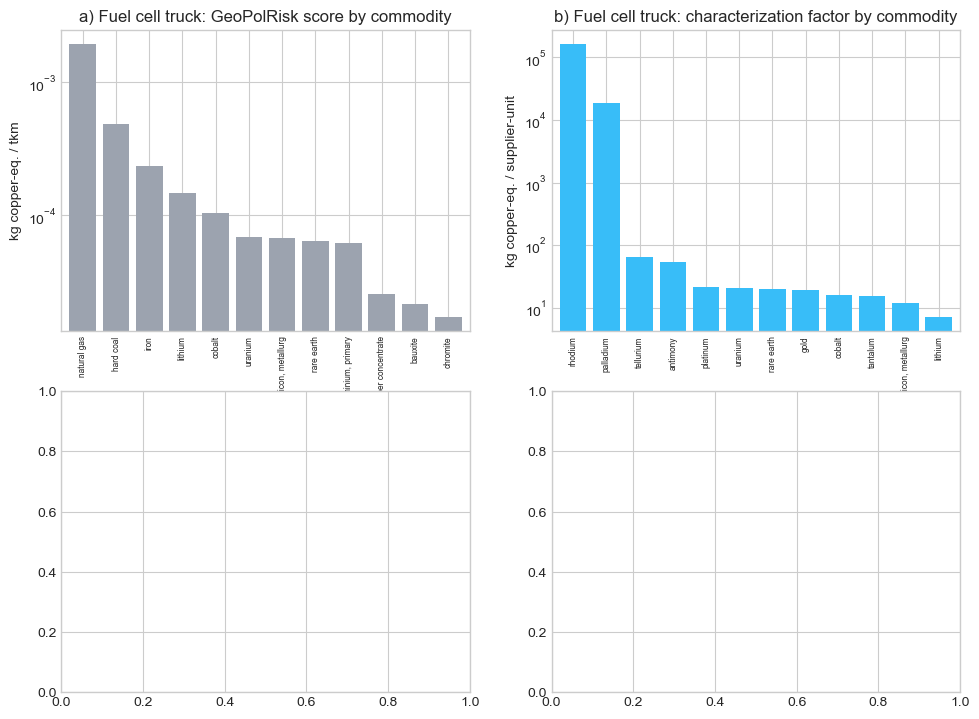

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.6))
axes = axes.flatten()

plot_a = commodity_summary.head(12)
plot_a["impact"].plot(kind="bar", ax=axes[0], color="#9ca3af", width=0.8)
axes[0].set_yscale("log")
axes[0].set_title(f"a) {focus_technology}: GeoPolRisk score by commodity")
axes[0].set_ylabel("kg copper-eq. / tkm")
axes[0].set_xticklabels(
    [tick.get_text()[:18] for tick in axes[0].get_xticklabels()],
    rotation=90,
)
axes[0].tick_params(axis="x", labelsize=6)

plot_b = (
    commodity_summary.dropna(subset=["CF"])
    .sort_values("CF", ascending=False)
    .head(12)
)
if plot_b.empty:
    axes[1].text(0.5, 0.5, "No CF summary available", ha="center", va="center")
    axes[1].set_axis_off()
else:
    plot_b["CF"].plot(kind="bar", ax=axes[1], color="#38bdf8", width=0.8)
    axes[1].set_yscale("log")
    axes[1].set_title(f"b) {focus_technology}: characterization factor by commodity")
    axes[1].set_ylabel("kg copper-eq. / supplier-unit")
    axes[1].set_xticklabels(
        [tick.get_text()[:18] for tick in axes[1].get_xticklabels()],
        rotation=90,
    )
axes[1].tick_params(axis="x", labelsize=6)


In [12]:
location_handles = []
location_labels = []

if location_matrix.empty:
    axes[2].text(0.5, 0.5, "No location split available", ha="center", va="center")
    axes[2].set_axis_off()
else:
    plot_c = location_matrix.head(8)
    default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    repeats = 1 + len(plot_c.columns) // max(len(default_cycle), 1)
    palette = (default_cycle * repeats)[: len(plot_c.columns)]
    palette_map = dict(zip(plot_c.columns, palette))
    palette_map.update(
        {
            "CH": "#0f766e",
            "CN": "#ef4444",
            "GLO": "#60a5fa",
            "RER": "#a78bfa",
        }
    )
    ordered_palette = [palette_map[label] for label in plot_c.columns]

    plot_c.plot(
        kind="bar",
        stacked=True,
        ax=axes[2],
        color=ordered_palette,
        width=0.8,
    )
    axes[2].set_title(f"c) {focus_technology}: score by commodity and supplier location")
    axes[2].set_ylabel("kg copper-eq. / tkm")
    axes[2].set_xticklabels(
        [tick.get_text()[:18] for tick in axes[2].get_xticklabels()],
        rotation=90,
    )
    axes[2].tick_params(axis="x", labelsize=6)
    location_handles, location_labels = axes[2].get_legend_handles_labels()

In [13]:
if location_labels:
    label_to_handle = dict(zip(location_labels, location_handles))
    ordered_labels = plot_c.sum(axis=0).sort_values(ascending=False).index.tolist()
    legend_labels = [label for label in ordered_labels if label in label_to_handle][:6]
    axes[2].legend(
        [label_to_handle[label] for label in legend_labels],
        legend_labels,
        title="Supplier location",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.22),
        ncol=min(3, len(legend_labels)),
        frameon=False,
        fontsize=6,
        title_fontsize=7,
    )

In [14]:
results_plot = results.set_index("technology").loc[technology_order]
results_plot["GeoPolRisk score [kg copper-eq. / tkm]"].plot(
    kind="bar",
    ax=axes[3],
    color=[TECH_COLORS[label] for label in technology_order],
    width=0.8,
)
axes[3].set_title("d) Route comparison")
axes[3].set_ylabel("kg copper-eq. / tkm")
axes[3].set_xticklabels([fill(label, 16) for label in technology_order], rotation=0)
axes[3].tick_params(axis="x", labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


<Figure size 640x480 with 0 Axes>

### Interpretation

- panels `a` to `c` zoom in on one focus route and split the GeoPolRisk result by commodity, CF intensity, and supplier location
- panel `d` keeps the direct technology comparison across the three freight services

In the default setup, the battery-electric truck still has the highest total GeoPolRisk score per
`ton kilometer`, but the fuel-cell route remains useful as a teaching example because its upstream
pattern shows a clearer location-sensitive hydrogen supply chain.

With the full method strategies enabled, aggregate-region fallback also recovers platinum-linked exchanges
in the PEM and fuel-cell chain. They are present in the matched output, but their contribution stays small
compared with the dominant `natural gas`, battery-metal, and other bulk-material families.


In [15]:
top_family_rows = []
for technology in technology_order:
    subset = (
        family_scores.loc[family_scores["technology"] == technology]
        .sort_values("GeoPolRisk score [kg copper-eq. / tkm]", ascending=False)
        .head(8)
        .copy()
    )
    subset["rank within technology"] = range(1, len(subset) + 1)
    top_family_rows.append(
        subset[
            [
                "technology",
                "rank within technology",
                "family",
                "commodity",
                "GeoPolRisk score [kg copper-eq. / tkm]",
            ]
        ]
    )

top_family_table = pd.concat(top_family_rows, ignore_index=True)
top_family_table


,technology,rank within technology,family,commodity,GeoPolRisk score [kg copper-eq. / tkm]
0,Battery electric truck,1,lithium,lithium,0.002449
1,Battery electric truck,2,cobalt,cobalt,0.001744
2,Battery electric truck,3,natural_gas,natural gas,0.001661
3,Battery electric truck,4,hard_coal,hard coal,0.000678
4,Battery electric truck,5,iron,iron,0.000275
5,Battery electric truck,6,rare_earth,rare earth,0.000211
6,Battery electric truck,7,aluminium_primary,"aluminium, primary",0.000128
7,Battery electric truck,8,palladium,palladium,0.000114
8,Fuel cell truck,1,natural_gas,natural gas,0.001952
9,Fuel cell truck,2,hard_coal,hard coal,0.000483


## 5) Map Country-Level Supplier Hotspots

The GeoPolRisk method is a **country-pair** method, so location matters twice:

- where the supplier is located
- where the consuming activity is located

For a compact map, we focus on the `Fuel cell truck` route because it has the richest explicit
country-coded supplier share in this trio and a clear hydrogen-linked upstream story.

Aggregate regions such as `GLO`, `RER`, or `APAC` are still part of the score, but they cannot be shown
as country points on the map. To keep the map readable, we therefore:

- report the aggregate-region share separately
- renormalize the explicit country-coded share to `100%` for the plotted supplier countries


In [16]:
focus_location_table = location_scores.loc[
    location_scores["technology"] == focus_technology
].copy()
focus_location_table["supplier location"] = focus_location_table["supplier location"].fillna(
    "Unknown"
)

is_country_code = focus_location_table["supplier location"].str.fullmatch(r"[A-Z]{2}")
focus_country_locations = focus_location_table.loc[is_country_code].copy()
focus_country_locations = focus_country_locations.merge(
    centroids,
    left_on="supplier location",
    right_on="code",
    how="left",
).dropna(subset=["lat", "lon"])

total_focus_score = float(
    focus_location_table["GeoPolRisk score [kg copper-eq. / tkm]"].sum()
)
mapped_country_score = float(
    focus_country_locations["GeoPolRisk score [kg copper-eq. / tkm]"].sum()
)
aggregate_score = total_focus_score - mapped_country_score

top_country_locations = focus_country_locations.sort_values(
    "GeoPolRisk score [kg copper-eq. / tkm]",
    ascending=False,
).head(12).copy()

top_country_locations["share of mapped-country score [%]"] = (
    100
    * top_country_locations["GeoPolRisk score [kg copper-eq. / tkm]"]
    / mapped_country_score
)

marker_sizes = (
    18
    + 45
    * top_country_locations["GeoPolRisk score [kg copper-eq. / tkm]"]
    / top_country_locations["GeoPolRisk score [kg copper-eq. / tkm]"].max()
)


In [17]:
display(
    top_country_locations[
        [
            "supplier location",
            "name",
            "GeoPolRisk score [kg copper-eq. / tkm]",
            "share of mapped-country score [%]",
        ]
    ]
)

print(f"Focus technology for the map: {focus_technology}")
print(
    "Country-coded supplier share available for the map: "
    f"{mapped_country_score:,.6f} kg copper-eq. / tkm "
    f"({100 * mapped_country_score / total_focus_score:,.1f}% of the route score)"
)
print(
    "Remaining score in aggregate regions not shown on the map: "
    f"{aggregate_score:,.6f} kg copper-eq. / tkm "
    f"({100 * aggregate_score / total_focus_score:,.1f}% of the route score)"
)


,supplier location,name,GeoPolRisk score [kg copper-eq. / tkm],share of mapped-country score [%]
38,RU,Russia,0.000638,25.681283
30,NO,Norway,0.000522,21.009040
46,US,United States,0.000513,20.665083
13,DZ,Algeria,0.000190,7.663997
12,DE,Germany,0.000124,5.012393
10,CN,China,0.000120,4.825617
36,QA,Qatar,0.000099,4.004954
4,AZ,Azerbaijan,0.000047,1.903959
29,NL,Netherlands,0.000044,1.786402
22,IT,Italy,0.000025,0.993224


Focus technology for the map: Fuel cell truck
Country-coded supplier share available for the map: 0.002483 kg copper-eq. / tkm (74.9% of the route score)
Remaining score in aggregate regions not shown on the map: 0.000832 kg copper-eq. / tkm (25.1% of the route score)


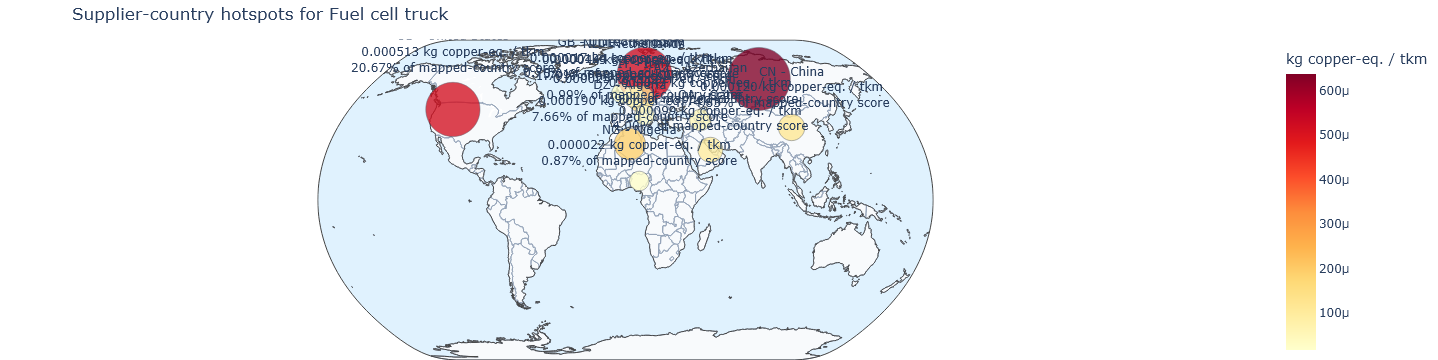

In [18]:
map_fig = go.Figure(
    go.Scattergeo(
        lon=top_country_locations["lon"],
        lat=top_country_locations["lat"],
        text=[
            (
                f"{row['supplier location']} - {row['name']}<br>"
                f"{row['GeoPolRisk score [kg copper-eq. / tkm]']:.6f} kg copper-eq. / tkm<br>"
                f"{row['share of mapped-country score [%]']:.2f}% of mapped-country score"
            )
            for _, row in top_country_locations.iterrows()
        ],
        mode="markers+text",
        textposition="top center",
        marker={
            "size": marker_sizes,
            "color": top_country_locations["GeoPolRisk score [kg copper-eq. / tkm]"],
            "colorscale": "YlOrRd",
            "opacity": 0.78,
            "line": {"color": "#374151", "width": 0.5},
            "colorbar": {"title": "kg copper-eq. / tkm"},
        },
        hoverinfo="text",
    )
)

map_fig.update_layout(
    title=f"Supplier-country hotspots for {focus_technology}",
    margin={"l": 0, "r": 0, "t": 40, "b": 0},
    geo={
        "projection_type": "natural earth",
        "showland": True,
        "landcolor": "#f8fafc",
        "showocean": True,
        "oceancolor": "#e0f2fe",
        "showcountries": True,
        "countrycolor": "#94a3b8",
    },
)

map_fig


## 6) Inspect Hotspots And Build A Sankey Diagram

We now stay with the same fuel-cell focus route and inspect the dominant matched supplier rows directly.

After that, we switch from `EdgeLCIA` to `SupplyChain` to generate a Sankey-style structural view.
The Sankey uses a level and cutoff threshold, so it is best read as a visualization of the dominant
pathways rather than as a replacement for the exact route score in `results`.

> **Why this code exists**
>
> - **Input:** the fuel-cell route, its matched hotspot rows, and a chosen supply-chain level/cutoff.
> - **Purpose:** connect the exact contribution table to the dominant upstream branches that create those contributions.
> - **Produces:** hotspot tables and an interactive Sankey HTML file; `results` remains the exact score source.
> - **If it fails:** keep the tabular results and try a shallower level or higher cutoff before rerunning the visualization.


In [19]:
focus_cf_table = cf_tables[focus_technology].copy()

focus_family_hotspots = (
    family_scores.loc[family_scores["technology"] == focus_technology]
    .sort_values("GeoPolRisk score [kg copper-eq. / tkm]", ascending=False)
    .head(10)
)

focus_exchange_hotspots = (
    focus_cf_table[
        [
            "family",
            "commodity",
            "supplier name",
            "supplier location",
            "consumer name",
            "amount",
            "CF",
            "impact",
        ]
    ]
    .sort_values("impact", ascending=False)
    .head(12)
    .rename(columns={"impact": "GeoPolRisk score [kg copper-eq. / tkm]"})
)

display(focus_family_hotspots)
focus_exchange_hotspots


,family,commodity,GeoPolRisk score [kg copper-eq. / tkm],technology
116,natural_gas,natural gas,0.001952,Fuel cell truck
106,hard_coal,hard coal,0.000483,Fuel cell truck
107,iron,iron,0.000234,Fuel cell truck
111,lithium,lithium,0.000146,Fuel cell truck
99,cobalt,cobalt,0.000104,Fuel cell truck
132,uranium,uranium,0.000068,Fuel cell truck
125,silicon_metallurgical,"silicon, metallurgical",0.000068,Fuel cell truck
122,rare_earth,rare earth,0.000065,Fuel cell truck
90,aluminium_primary,"aluminium, primary",0.000061,Fuel cell truck
100,copper_concentrate,copper concentrate,0.000026,Fuel cell truck


,family,commodity,supplier name,supplier location,consumer name,amount,CF,GeoPolRisk score [kg copper-eq. / tkm]
836,natural_gas,natural gas,"Natural gas, at production offshore",NO,"Natural gas, at production",0.003649,0.069179,0.000252
88,natural_gas,natural gas,"Natural gas, at production",RU,"Natural gas, production RU, at long-distance p...",0.001049,0.210450,0.000221
794,natural_gas,natural gas,"Natural gas, at production onshore",US,"Natural gas, at production",0.002626,0.069179,0.000182
898,natural_gas,natural gas,"Natural gas, at production",US,"Natural gas, liquefied, at liquefaction plant",0.002455,0.069179,0.000170
174,iron,iron,"Iron ore, 46% Fe, at mine",GLO,"Iron ore, 65% Fe, at beneficiation",0.009310,0.014378,0.000134
928,hard_coal,hard coal,"Hard coal, at mine",RU,"Hard coal, at regional storage",0.003201,0.041433,0.000133
823,natural_gas,natural gas,"Natural gas, at production onshore",RU,"Natural gas, at production",0.001857,0.069179,0.000128
904,natural_gas,natural gas,"Natural gas, at consumer",US,"Natural gas, burned in power plant or heat plant",0.001528,0.069179,0.000106
181,cobalt,cobalt,"Cobalt, at plant",GLO,Cobalt sulfate,0.000006,16.142064,0.000104
948,natural_gas,natural gas,"Natural gas, at production",NO,"Natural gas, production NO, at long-distance p...",0.001497,0.069179,0.000104


Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]
Fallback follow-up: 24 edge(s) were resolved later; 0 edge(s) remain unmatched.
Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
Resolving contained locations [4/5]
Resolving global locations    [5/5]


,focus technology,SupplyChain score at current cutoff [kg copper-eq. / tkm],rows in Sankey table,saved HTML
0,Fuel cell truck,0.003316,108,D3-05_fuel_cell_truck_geopolrisk_sankey.html


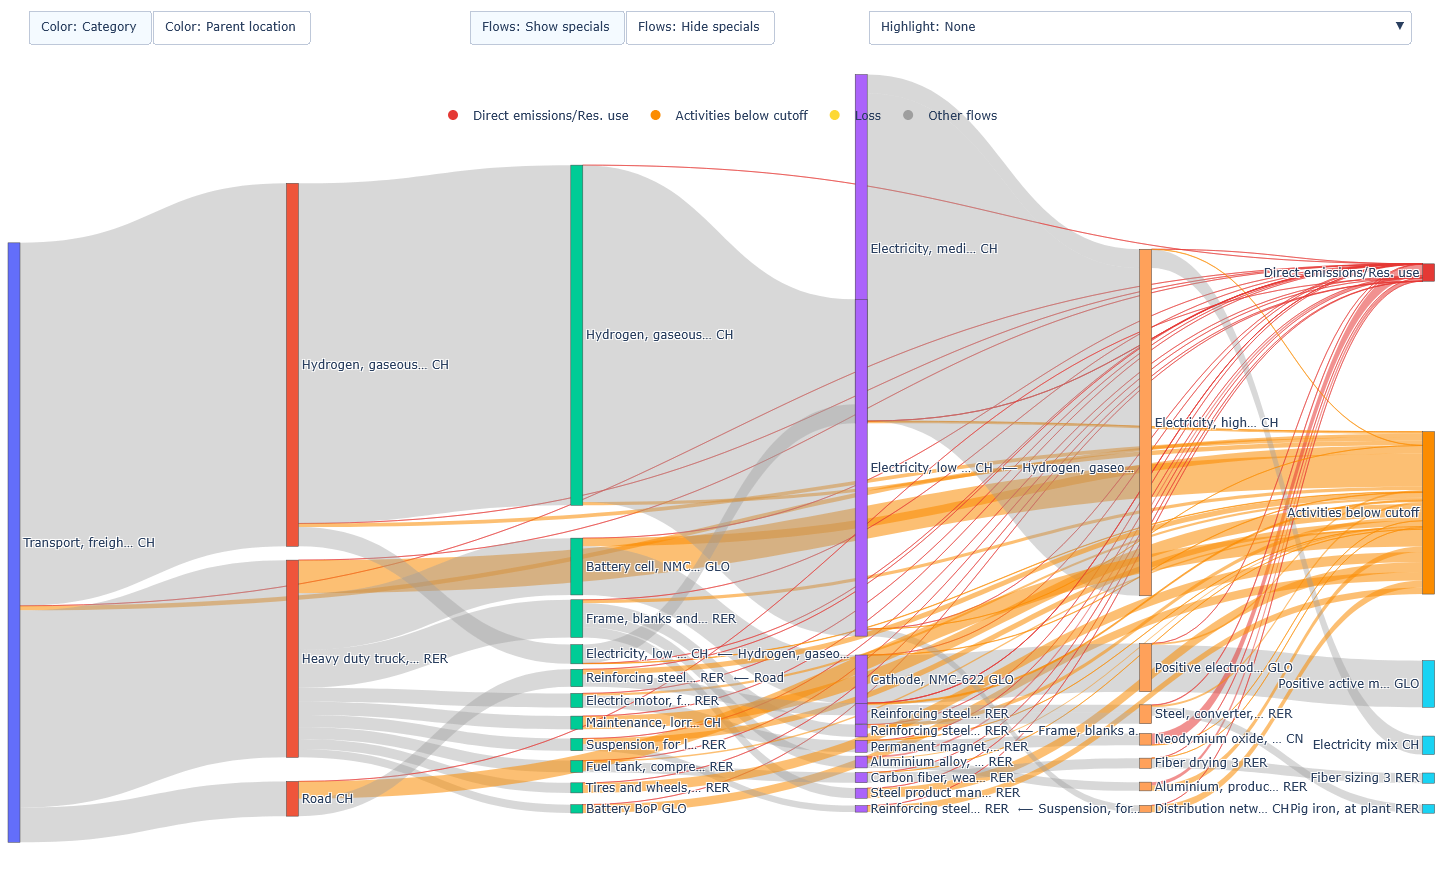

In [20]:
NOTEBOOK_DIR = Path(".")
focus_slug = slugify(focus_technology)
sankey_path = NOTEBOOK_DIR / f"D3-05_{focus_slug}_geopolrisk_sankey.html"

supply_chain = SupplyChain(
    activity=activities[focus_technology],
    method=str(method_path),
    amount=1,
    level=5,
    cutoff=0.01,
    cutoff_basis="total",
    collapse_markets=True,
)

supply_chain_score = float(supply_chain.bootstrap())
supply_df, _, _ = supply_chain.calculate()

sankey_fig = supply_chain.plot_sankey(
    supply_df,
    width_max=1600,
    height_max=880,
    node_instance_mode="by_parent",
    node_thickness=12,
    node_pad=8,
)
# sankey_fig.write_html(sankey_path, include_plotlyjs="cdn")

sankey_summary = pd.DataFrame(
    [
        {
            "focus technology": focus_technology,
            "SupplyChain score at current cutoff [kg copper-eq. / tkm]": supply_chain_score,
            "rows in Sankey table": len(supply_df),
            "saved HTML": str(sankey_path),
        }
    ]
)

display(sankey_summary)
sankey_fig


## Guided checkpoint: move from a score to an explanation

- **Predict:** Before reading panel `d`, choose which freight technology you expect to have the highest GeoPolRisk score and name one likely material driver.
- **Run:** Use `results`, `top_family_table`, the country map, and the Sankey figure to answer the three prompts in the TODO cell.
- **Interpret:** Connect the highest route score to its non-iron commodity families, then distinguish explicit country hotspots from contributions assigned to aggregate regions.
- **Check:** In the default comparison, the battery-electric truck has the highest total score. The map and Sankey focus on the fuel-cell route, so do not mistake the visualization focus for the highest-scoring route. If the ranking differs, confirm that the three original `activity_specs` are still selected.
- **Extension:** Complete the assumption-change exercise below and report which part of the explanation—total score, family composition, or hotspot geography—changes most.


In [ ]:
# TODO
# 1. Name the route with the highest GeoPolRisk score.
# 2. Identify the main non-iron family hotspots for that route.
# 3. Summarize the top mapped supplier countries and the aggregate-region share.


## Exercise

Change one of the comparison assumptions and rerun the notebook from section 4 onward.

Good options:

- replace the `Battery electric truck` with the LFP variant
- replace the `Fuel cell truck` with the `hydrogen from SMR of natural gas` variant
- switch from `regional delivery` to `urban delivery`

Then compare:

- the total GeoPolRisk score
- the family composition
- the supplier-country hotspot pattern


In [ ]:
# TODO
# 1. Edit one of the names in `activity_specs`.
# 2. Rerun the GeoPolRisk calculation cells.
# 3. Compare how the route score, family shares, and map hotspots change.


## Recap

After this notebook, you should now be able to:

- run a BAFU-specific GeoPolRisk paired method with `EdgeLCIA`
- compare three transport services on a shared service unit, `1 ton kilometer`
- move from total route score to commodity-family interpretation using the match report
- separate explicit country hotspots from aggregate-region contributions on a supplier map
- use `SupplyChain` to visualize the dominant pathways behind a GeoPolRisk result

`D3-06` can now reuse this logic in a capstone setting together with the scenario-oriented work from earlier in the course.
